In [2]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load Dataset


In [4]:
from google.colab import files
uploaded = files.upload()

Saving Density 800-1300.csv to Density 800-1300.csv


In [6]:
df = pd.read_csv("Density 800-1300.csv", comment='#')

# Rename columns for clarity
df = df.rename(columns={
    'P1': 'Density (kg/m³)',
    'P2': 'Total Deformation (mm)'
})

print(df.head())

   Name  Density (kg/m³)  Total Deformation (mm)
0  DP 0             1000              748.083253
1  DP 1             1100              735.760158
2  DP 2             1200              724.026615
3  DP 3             1300              712.837071
4  DP 4             1400              702.150748


Define Variables

In [8]:
x = df['Total Deformation (mm)'].values
y = df['Density (kg/m³)'].values
df.head()

,Name,Density (kg/m³),Total Deformation (mm)
0,DP 0,1000,748.083253
1,DP 1,1100,735.760158
2,DP 2,1200,724.026615
3,DP 3,1300,712.837071
4,DP 4,1400,702.150748


Calculate Mean

In [9]:
x_mean = np.mean(x)
y_mean = np.mean(y)

Calculate Slope (m) and Intercept (b)

Formula used:

m=
∑(x−
x
ˉ
)
2
∑(x−
x
ˉ
)(y−
y
ˉ
	​

)
	​


In [10]:
numerator = np.sum((x - x_mean) * (y - y_mean))
denominator = np.sum((x - x_mean)**2)

m = numerator / denominator
b = y_mean - m * x_mean

print("Slope (m):", m)
print("Intercept (b):", b)

Slope (m): -9.267638953788559
Intercept (b): 7934.572623997483


Model Equation
y = mx + b

In [11]:
y_pred = m * x + b

Calculate Error

In [12]:
# Mean Squared Error
mse = np.mean((y - y_pred)**2)

# Root Mean Squared Error
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)

MSE: 759.501301896645
RMSE: 27.559051179179683


Calculate R² Score

Formula:

R
2
=1−
∑(y−
y
ˉ
	​

)
2
∑(y−y
pred
	​

)
2
	​


In [13]:
ss_total = np.sum((y - y_mean)**2)
ss_residual = np.sum((y - y_pred)**2)

r2 = 1 - (ss_residual / ss_total)

print("R² Score:", r2)

R² Score: 0.9912382175946504


Predict Experimental Value

In [14]:
x_new = 720   # example deformation

y_new = m * x_new + b

print("Predicted Density:", y_new)

Predicted Density: 1261.8725772697208


Verify Prediction

In [15]:
# Find closest actual value
closest_index = np.argmin(abs(x - x_new))

actual_value = y[closest_index]

print("Actual Density:", actual_value)
print("Predicted Density:", y_new)
print("Error:", abs(actual_value - y_new))

Actual Density: 1240
Predicted Density: 1261.8725772697208
Error: 21.87257726972075


Plot Graph

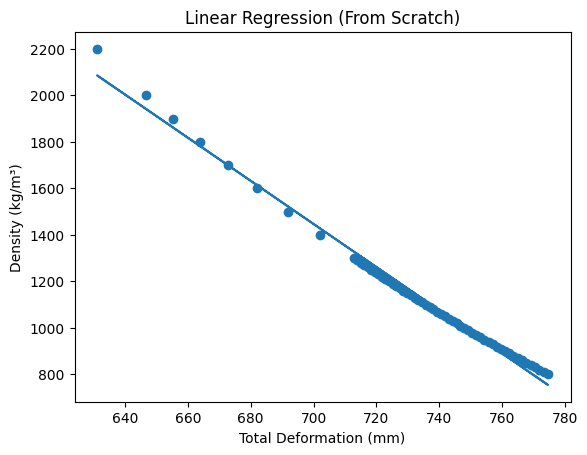

In [16]:
plt.figure()

# Scatter (actual data)
plt.scatter(x, y)

# Line (model)
plt.plot(x, y_pred)

plt.xlabel("Total Deformation (mm)")
plt.ylabel("Density (kg/m³)")
plt.title("Linear Regression (From Scratch)")

plt.show()

FINAL OUTPUT SUMMARY :
I implemented a linear regression model from scratch using statistical formulas for slope and intercept. The model was evaluated using RMSE and R² score, and predictions were validated against actual experimental values. The plotted graph confirms the linear trend between deformation and density.

Although the linear model works well, slight curvature in data suggests a polynomial model would give better accuracy.

Polynomial Model Concept

Create Polynomial Features

In [17]:
# Using same x, y from linear model

# Create polynomial terms
X_poly = np.column_stack((np.ones(len(x)), x, x**2))

Find Coefficients (Normal Equation)

 Formula used:

β=(X
T
X)
−1
X
T
y

In [18]:
# Compute coefficients
beta = np.linalg.inv(X_poly.T @ X_poly) @ X_poly.T @ y

a = beta[0]
b = beta[1]
c = beta[2]

print("a:", a)
print("b:", b)
print("c:", c)

a: 17989.972444070507
b: -37.55278735855066
c: 0.019837016312421123


Predictions

In [19]:
y_pred_poly = a + b*x + c*(x**2)

Error Calculation

In [ ]:
mse_poly = np.mean((y - y_pred_poly)**2)
rmse_poly = np.sqrt(mse_poly)

print("MSE (Polynomial):", mse_poly)
print("RMSE (Polynomial):", rmse_poly)

R² Score

In [20]:
ss_total = np.sum((y - y.mean())**2)
ss_residual_poly = np.sum((y - y_pred_poly)**2)

r2_poly = 1 - (ss_residual_poly / ss_total)

print("R² (Polynomial):", r2_poly)

R² (Polynomial): 0.9999601353707486


Predict Experimental Value

In [ ]:
x_new = 720   # same value as before

y_new_poly = a + b*x_new + c*(x_new**2)

print("Predicted Density (Polynomial):", y_new_poly)

Verification

In [ ]:
closest_index = np.argmin(abs(x - x_new))

actual_value = y[closest_index]

print("Actual Density:", actual_value)
print("Predicted Density (Poly):", y_new_poly)
print("Error:", abs(actual_value - y_new_poly))

Plot Graph (CURVED)

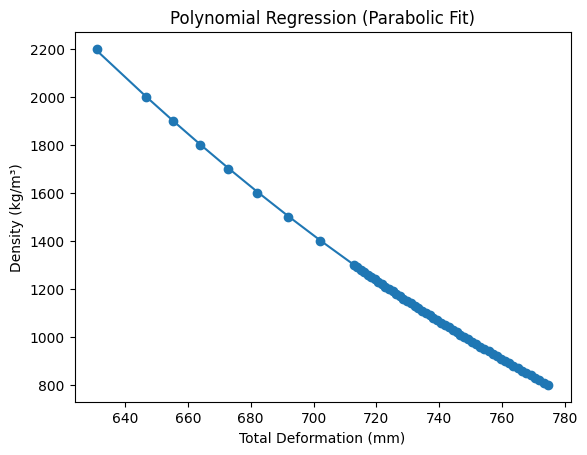

In [21]:
# Sort values for smooth curve
sorted_index = np.argsort(x)
x_sorted = x[sorted_index]
y_sorted = y_pred_poly[sorted_index]

plt.figure()

# Actual data
plt.scatter(x, y)

# Polynomial curve
plt.plot(x_sorted, y_sorted)

plt.xlabel("Total Deformation (mm)")
plt.ylabel("Density (kg/m³)")
plt.title("Polynomial Regression (Parabolic Fit)")

plt.show()

MODEL COMPARISON

In [22]:
# ================================
# LINEAR MODEL (from scratch)
# ================================

# Predictions
y_pred_linear = m * x + b

# Errors
mse_linear = np.mean((y - y_pred_linear)**2)
rmse_linear = np.sqrt(mse_linear)

# R2
ss_total = np.sum((y - np.mean(y))**2)
ss_res_linear = np.sum((y - y_pred_linear)**2)
r2_linear = 1 - (ss_res_linear / ss_total)


# ================================
# POLYNOMIAL MODEL (from scratch)
# ================================

# Predictions
y_pred_poly = a + b*x + c*(x**2)

# Errors
mse_poly = np.mean((y - y_pred_poly)**2)
rmse_poly = np.sqrt(mse_poly)

# R2
ss_res_poly = np.sum((y - y_pred_poly)**2)
r2_poly = 1 - (ss_res_poly / ss_total)


# ================================
# COMPARISON TABLE
# ================================

comparison = pd.DataFrame({
    "Metric": ["MSE", "RMSE", "R² Score"],
    "Linear Model": [mse_linear, rmse_linear, r2_linear],
    "Polynomial Model": [mse_poly, rmse_poly, r2_poly]
})

# Round values for neat display
comparison = comparison.round(5)

print(comparison)

     Metric  Linear Model  Polynomial Model
0       MSE  6.355554e+07           3.45560
1      RMSE  7.972173e+03           1.85893
2  R² Score -7.321914e+02           0.99996


PLOT BOTH IN ONE GRAPH

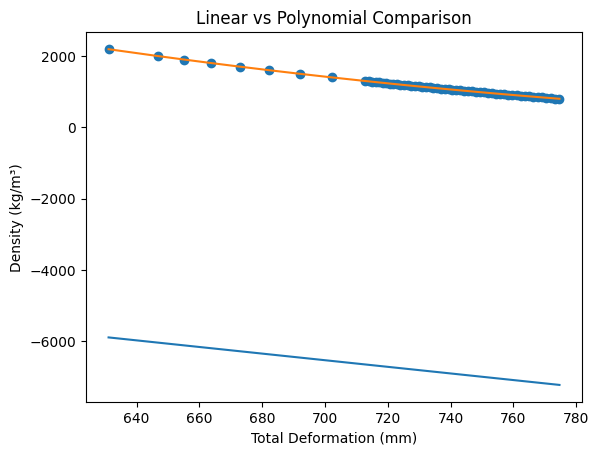

In [23]:
# Sort for smooth curve
sorted_idx = np.argsort(x)
x_sorted = x[sorted_idx]

y_linear_sorted = y_pred_linear[sorted_idx]
y_poly_sorted = y_pred_poly[sorted_idx]

plt.figure()

# Actual data
plt.scatter(x, y)

# Linear line
plt.plot(x_sorted, y_linear_sorted)

# Polynomial curve
plt.plot(x_sorted, y_poly_sorted)

plt.xlabel("Total Deformation (mm)")
plt.ylabel("Density (kg/m³)")
plt.title("Linear vs Polynomial Comparison")

plt.show()

The polynomial model shows significantly lower error and higher R² compared to the linear model, confirming that the relationship is non-linear.